In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv("C:/Users/kotha/OneDrive/Desktop/Saranya/DataScience/PredictionWithCircleCI/artifacts/raw/data.csv")


In [4]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
df.duplicated().sum()

0

In [6]:
df.isna().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [8]:
df.describe(include='all')

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
count,150.000000,150.000000,150.000000,150.000000,150.000000,150
unique,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,NaN,Iris-setosa
freq,NaN,NaN,NaN,NaN,NaN,50
mean,75.500000,5.843333,3.054000,3.758667,1.198667,NaN
std,43.445368,0.828066,0.433594,1.764420,0.763161,NaN
min,1.000000,4.300000,2.000000,1.000000,0.100000,NaN
25%,38.250000,5.100000,2.800000,1.600000,0.300000,NaN
50%,75.500000,5.800000,3.000000,4.350000,1.300000,NaN
75%,112.750000,6.400000,3.300000,5.100000,1.800000,NaN


In [9]:
df["Species"].value_counts()

Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: Species, dtype: int64

In [10]:
df.drop("Id", axis=1, inplace=True)

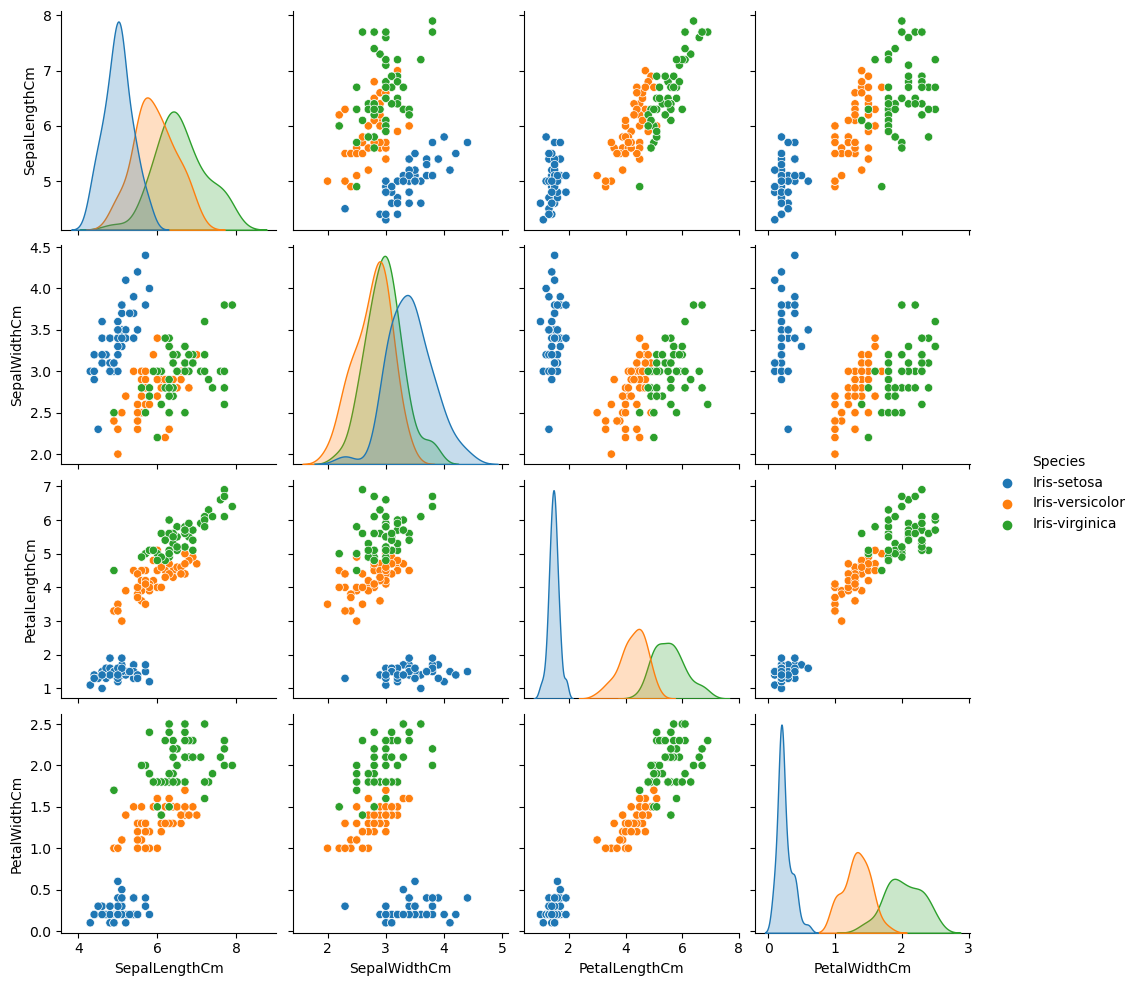

In [11]:
sns.pairplot(df, hue="Species")
plt.show()

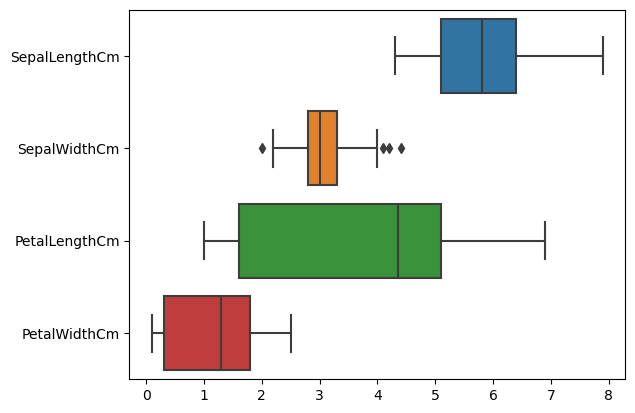

In [12]:
sns.boxplot(data=df,orient="h")
plt.show()

c:\Users\kotha\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


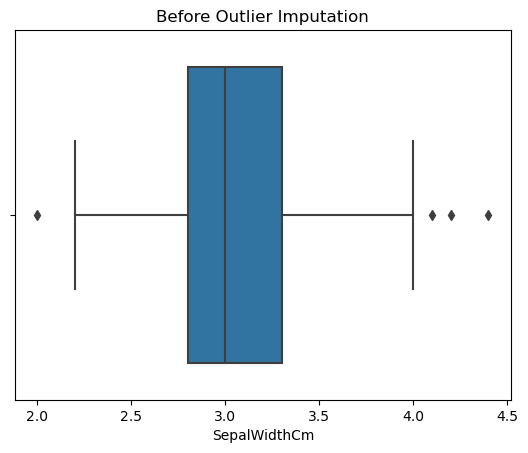

In [13]:
sns.boxplot(df["SepalWidthCm"])
plt.title("Before Outlier Imputation")
plt.show()

In [16]:
Q1 = df["SepalWidthCm"].quantile(0.25)
Q3 = df["SepalWidthCm"].quantile(0.75)
IQR = Q3 - Q1

Lower_value = Q1 - 1.5 * IQR
Upper_value = Q3 + 1.5 * IQR 

sepal_median = np.median(df["SepalWidthCm"])

In [17]:
sepal_median

3.0

In [18]:
for i in df["SepalWidthCm"]:
    if i> Upper_value or i<Lower_value:
        df["SepalWidthCm"] = df["SepalWidthCm"].replace(i,sepal_median)

c:\Users\kotha\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


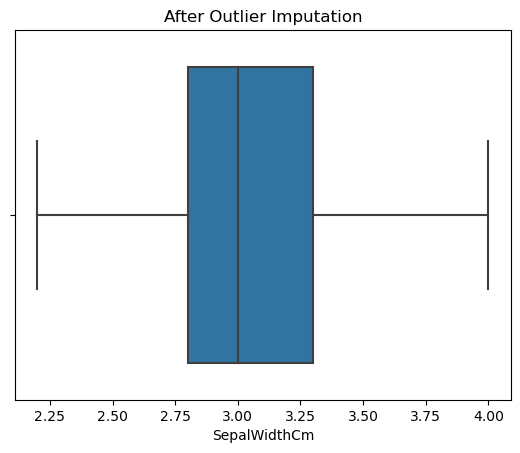

In [19]:
sns.boxplot(df["SepalWidthCm"])
plt.title("After Outlier Imputation")
plt.show()

###MODEL TRAINING

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import accuracy_score,confusion_matrix

In [22]:
df.columns

Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [23]:
X = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
Y = df["Species"]

In [24]:
X_train,X_test,y_train,y_test = train_test_split(X,Y , test_size=0.2 , random_state=42)

In [25]:
tree_clf = DecisionTreeClassifier(criterion="gini" , max_depth=30 , random_state=42)

In [26]:
tree_clf.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=30, random_state=42)

In [27]:
y_pred = tree_clf.predict(X_test)

In [28]:
y_pred

array(['Iris-versicolor', 'Iris-setosa', 'Iris-virginica',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-setosa',
       'Iris-versicolor', 'Iris-virginica', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-virginica', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-versicolor', 'Iris-virginica',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-virginica',
       'Iris-setosa', 'Iris-virginica', 'Iris-setosa', 'Iris-virginica',
       'Iris-virginica', 'Iris-virginica', 'Iris-virginica',
       'Iris-virginica', 'Iris-setosa', 'Iris-setosa'], dtype=object)

In [30]:
accuracy = accuracy_score(y_test , y_pred)
print(accuracy)

1.0


In [31]:
conf_matrix = confusion_matrix(y_test,y_pred)
print(conf_matrix)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


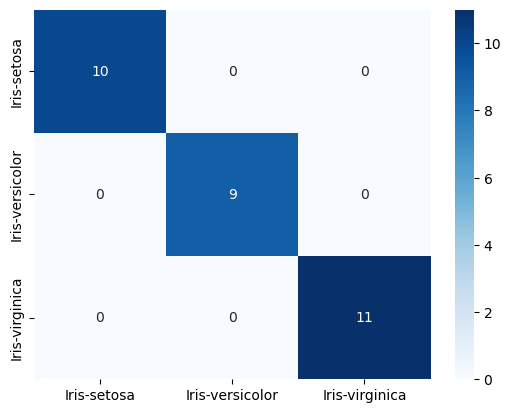

In [32]:
sns.heatmap(conf_matrix,annot=True , cmap="Blues" , xticklabels=tree_clf.classes_ , yticklabels=tree_clf.classes_)
plt.show()

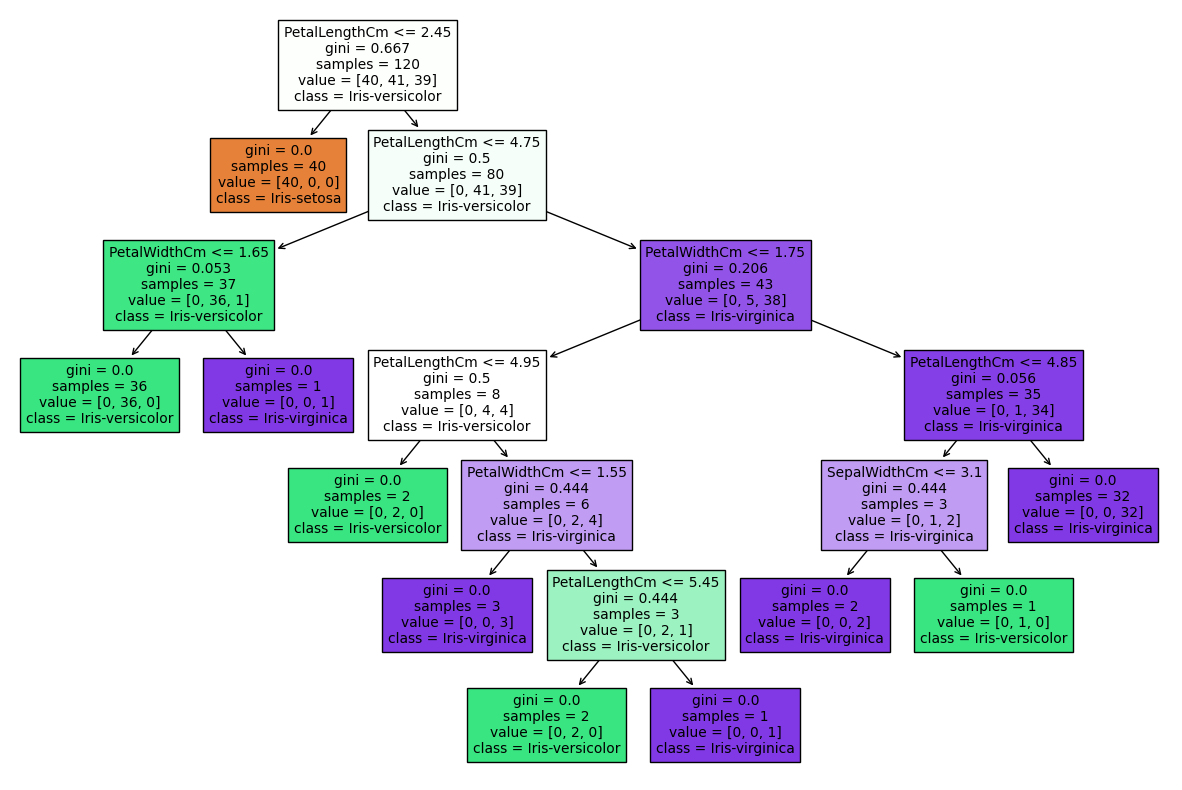

In [33]:
plt.figure(figsize=(15,10))
plot_tree(tree_clf , filled=True , feature_names=X.columns , class_names=tree_clf.classes_)
plt.show()

In [34]:
tree_clf.feature_importances_

array([0.        , 0.01667014, 0.90614339, 0.07718647])

In [35]:
X.columns

Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'], dtype='object')